# Generación de Texto con modelos GPT

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arlexpin/icesi-nlp/blob/main/Entregables/Sesion5/Work5.ipynb)

# Descripción del proyecto

Este notebook desarrolla un flujo de **generación de texto en español** con un modelo **GPT-2 preentrenado** (`mrm8488/spanish-gpt2`).

## Objetivos
1. Probar generación de texto a partir de un contexto inicial.
2. Analizar probabilidades de tokens en cada paso.
3. Implementar una función propia de generación incremental (greedy y muestreo).
4. Realizar **fine-tuning** con un dataset de recetas de cocina.
5. Comparar el comportamiento del modelo base vs. el modelo ajustado.

## Resultado esperado
Después del ajuste, el modelo genera texto con estilo más cercano al dominio culinario, mostrando cómo el dataset de entrenamiento cambia la narrativa del modelo.

### Referencias
- Dataset: https://huggingface.co/datasets/Frorozcol/recetas-cocina
- [Improving Language Understanding by Generative Pre-Training](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf)
- [Natural Language Processing with Transformers: Building Language Applications With Hugging Face](https://www.amazon.com/Natural-Language-Processing-Transformers-Applications/dp/1098103246)
- [GPT2 Spanish](https://huggingface.co/mrm8488/spanish-gpt2)
- [Fine-Tune a non-Englush GPT-2 Model with Huggingface](https://www.philschmid.de/fine-tune-a-non-english-gpt-2-model-with-huggingface)

# Universidad Icesi

## Maestria en IA Aplicada

Catedra: **Procesamiento de Lenguaje Natural**

Grupo: **Golf**
Realizado por:
- **Arlex Pino**
- **Alfredo Aponte**

## Detección de entorno y preparación de dependencias

Este bloque identifica si el notebook se está ejecutando en **Google Colab** o en un entorno local (por ejemplo, **VSCode + Jupyter**).

- Se obtiene la lista de paquetes instalados en el entorno activo.
- Se define la variable `IN_COLAB`, que vale `True` cuando detecta `google-colab`.
- Esta variable se usa más adelante para decidir si instalar dependencias automáticamente o solo mostrar instrucciones para entorno local.

Con esto evitamos ejecutar comandos de sistema incompatibles entre plataformas y mantenemos el notebook portable.

In [ ]:
import pkg_resources
import warnings

# Suprime advertencias para que la salida del notebook sea mas limpia.
warnings.filterwarnings('ignore')

# Detecta si el entorno actual corresponde a Google Colab.
installed_packages = [package.key for package in pkg_resources.working_set]
IN_COLAB = 'google-colab' in installed_packages

print(f"Entorno detectado: {'Google Colab' if IN_COLAB else 'Local (VSCode/Jupyter)'}")

Entorno detectado: Local (VSCode/Jupyter)


In [ ]:
from pathlib import Path
import subprocess
import sys

# Instalacion condicional para mantener compatibilidad entre Colab y VSCode.
if IN_COLAB:
    print('Instalando dependencias en Colab...')
    subprocess.run(
        [
            sys.executable,
            '-m',
            'pip',
            'install',
            '-q',
            'lightning',
            'datasets',
            'transformers[torch]',
            'sentence-transformers',
            'torchinfo',
            'evaluate',
        ],
        check=True,
    )
    print('Dependencias instaladas en Colab.')
else:
    print('Entorno local detectado (VSCode/Jupyter).')
    print('Usa tu entorno virtual y ejecuta, si hace falta:')

    root = Path.cwd()
    req_candidates = [
        root / 'Sesion 2' / 'requirements.txt',
        root / 'requirements.txt',
    ]
    req_path = next((p for p in req_candidates if p.exists()), None)

    if req_path:
        print(f'  {sys.executable} -m pip install -r "{req_path}"')
    else:
        print('  python -m pip install lightning datasets "transformers[torch]" sentence-transformers torchinfo evaluate')

Entorno local detectado (VSCode/Jupyter).
Usa tu entorno virtual y ejecuta, si hace falta:
  python -m pip install lightning datasets "transformers[torch]" sentence-transformers torchinfo evaluate


## Generative pre-training Transformer - GPT

### Carga del modelo base y tokenizador

En esta sección se prepara el modelo `mrm8488/spanish-gpt2` para generación de texto.

- Se importan PyTorch y las clases de Hugging Face necesarias.
- Se detecta automáticamente el dispositivo disponible: GPU (`cuda`) o CPU.
- Se descargan/cargan el tokenizador y el modelo causal (`AutoModelForCausalLM`).
- Si el tokenizador no tiene `pad_token`, se reutiliza `eos_token` para evitar errores en padding y generación.
- Se sincroniza `pad_token_id` en la configuración del modelo.
- Se redimensionan embeddings para que coincidan con el tamaño final del vocabulario del tokenizador.


In [28]:
import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer

# Selecciona GPU en Colab o VSCode si esta disponible; en caso contrario usa CPU.
device = "cuda" if torch.cuda.is_available() else "cpu"

# Modelo GPT-2 en espanol preentrenado en Hugging Face Hub.
model_name = "mrm8488/spanish-gpt2"

# Carga de tokenizador y modelo de lenguaje causal.
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

# Si no existe token de padding, usamos EOS para mantener compatibilidad en inferencia.
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Sincroniza el id de padding entre tokenizador y configuracion del modelo.
model.config.pad_token_id = tokenizer.pad_token_id

# Ajusta la capa de embeddings al tamano actual del vocabulario del tokenizador.
model.resize_token_embeddings(len(tokenizer))

model

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50266, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.0, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2SdpaAttention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.0, inplace=False)
          (resid_dropout): Dropout(p=0.0, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.0, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50266, bias=False)
)

In [29]:
from collections import Counter

# Dashboard descriptivo del modelo cargado (resultado anterior)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
non_trainable_params = total_params - trainable_params

num_layers = getattr(model.config, "n_layer", None)
num_heads = getattr(model.config, "n_head", None)
hidden_size = getattr(model.config, "n_embd", None)
context_size = getattr(model.config, "n_ctx", getattr(model.config, "n_positions", None))
vocab_size = len(tokenizer)

module_types = Counter(type(m).__name__ for _, m in model.named_modules())
top_modules = module_types.most_common(8)

dashboard = {
    "Modelo": model_name,
    "Entorno": "Google Colab" if IN_COLAB else "Local (VSCode/Jupyter)",
    "Dispositivo": device,
    "Vocabulario (tokenizer)": vocab_size,
    "Capas Transformer": num_layers,
    "Cabezas de atención": num_heads,
    "Tamaño oculto (n_embd)": hidden_size,
    "Longitud de contexto": context_size,
    "Parámetros totales": f"{total_params:,}",
    "Parámetros entrenables": f"{trainable_params:,}",
    "Parámetros no entrenables": f"{non_trainable_params:,}",
}

print("=== DASHBOARD: MODELO GPT-2 EN ESPAÑOL ===")
for k, v in dashboard.items():
    print(f"{k:30}: {v}")

print("\n=== Top tipos de módulos internos ===")
for name, count in top_modules:
    print(f"{name:30}: {count}")

# Si pandas ya está disponible en el notebook, mostrar también como tabla
if "pd" in globals():
    dashboard_df = pd.DataFrame(
        {"Métrica": list(dashboard.keys()), "Valor": list(dashboard.values())}
    )
    modules_df = pd.DataFrame(top_modules, columns=["Tipo de módulo", "Cantidad"])
    display(dashboard_df)
    display(modules_df)

=== DASHBOARD: MODELO GPT-2 EN ESPAÑOL ===
Modelo                        : mrm8488/spanish-gpt2
Entorno                       : Local (VSCode/Jupyter)
Dispositivo                   : cuda
Vocabulario (tokenizer)       : 50266
Capas Transformer             : 12
Cabezas de atención           : 12
Tamaño oculto (n_embd)        : 768
Longitud de contexto          : 1024
Parámetros totales            : 124,446,720
Parámetros entrenables        : 124,446,720
Parámetros no entrenables     : 0

=== Top tipos de módulos internos ===
Conv1D                        : 48
Dropout                       : 37
LayerNorm                     : 25
GPT2Block                     : 12
GPT2SdpaAttention             : 12
GPT2MLP                       : 12
NewGELUActivation             : 12
Embedding                     : 2


,Métrica,Valor
0,Modelo,mrm8488/spanish-gpt2
1,Entorno,Local (VSCode/Jupyter)
2,Dispositivo,cuda
3,Vocabulario (tokenizer),50266
4,Capas Transformer,12
5,Cabezas de atención,12
6,Tamaño oculto (n_embd),768
7,Longitud de contexto,1024
8,Parámetros totales,"124,446,720"
9,Parámetros entrenables,"124,446,720"


,Tipo de módulo,Cantidad
0,Conv1D,48
1,Dropout,37
2,LayerNorm,25
3,GPT2Block,12
4,GPT2SdpaAttention,12
5,GPT2MLP,12
6,NewGELUActivation,12
7,Embedding,2


In [30]:
# Extrae los nombres de todos los submodulos del modelo (capas, bloques de atencion, etc.)
# para inspeccion rapida de su arquitectura interna.
modules = [m for m, _ in model.named_modules()]
modules

['',
 'transformer',
 'transformer.wte',
 'transformer.wpe',
 'transformer.drop',
 'transformer.h',
 'transformer.h.0',
 'transformer.h.0.ln_1',
 'transformer.h.0.attn',
 'transformer.h.0.attn.c_attn',
 'transformer.h.0.attn.c_proj',
 'transformer.h.0.attn.attn_dropout',
 'transformer.h.0.attn.resid_dropout',
 'transformer.h.0.ln_2',
 'transformer.h.0.mlp',
 'transformer.h.0.mlp.c_fc',
 'transformer.h.0.mlp.c_proj',
 'transformer.h.0.mlp.act',
 'transformer.h.0.mlp.dropout',
 'transformer.h.1',
 'transformer.h.1.ln_1',
 'transformer.h.1.attn',
 'transformer.h.1.attn.c_attn',
 'transformer.h.1.attn.c_proj',
 'transformer.h.1.attn.attn_dropout',
 'transformer.h.1.attn.resid_dropout',
 'transformer.h.1.ln_2',
 'transformer.h.1.mlp',
 'transformer.h.1.mlp.c_fc',
 'transformer.h.1.mlp.c_proj',
 'transformer.h.1.mlp.act',
 'transformer.h.1.mlp.dropout',
 'transformer.h.2',
 'transformer.h.2.ln_1',
 'transformer.h.2.attn',
 'transformer.h.2.attn.c_attn',
 'transformer.h.2.attn.c_proj',
 'tran

Observermos un ejemplo de generación simple.

In [31]:
# Texto inicial (prompt) para generar continuacion
text = "Quiero algo rico con pollo"
best = 10  # Numero de tokens con mayor probabilidad a mostrar

# Evita calculo de gradientes durante inferencia (ahorra memoria y aceleracion)
with torch.no_grad():
    # Tokeniza el texto inicial y lo convierte a tensor en el dispositivo seleccionado (CPU o GPU)
    tokens = tokenizer(text, return_tensors='pt')['input_ids'].to(device)
    print("Dimensiones de la entrada:", tokens.shape)
    
    # Pasa el texto al modelo para obtener los logits (puntuaciones sin normalizar)
    output = model(input_ids=tokens)
    print("Dimensiones de la salida:", output.logits.shape)
    
    # Extrae solo los logits del ultimo token de la secuencia (lo que viene despues)
    output = output.logits[0, -1, :]
    print("Dimensiones del último token de la secuencia:", output.shape)
    
    # Normaliza los logits para obtener probabilidades (suma = 1)
    probs = torch.softmax(output, dim=-1)
    print("Dimensiones de la probabilidad de los tokens:", probs.shape)
    
    # Ordena los indices por probabilidad de mayor a menor
    sorted_probs = torch.argsort(probs, dim=-1, descending=True)
    
    # Muestra los top-N tokens decodificados con sus probabilidades (%) - funciona igual en Colab y VSCode
    print({tokenizer.decode(token): f"{prob.cpu().numpy() * 100:.2f}%" for token, prob in zip(sorted_probs[:best], probs[sorted_probs[:best]])})

Dimensiones de la entrada: torch.Size([1, 5])
Dimensiones de la salida: torch.Size([1, 5, 50266])
Dimensiones del último token de la secuencia: torch.Size([50266])
Dimensiones de la probabilidad de los tokens: torch.Size([50266])
{'.': '38.99%', ' y': '17.26%', ',': '11.24%', ' frito': '4.53%', '...': '3.22%', ' para': '3.00%', ' a': '1.90%', ' en': '1.57%', ' con': '0.89%', '!': '0.80%'}


,tensor,shape,ndim,numel,dtype,device,memory_mb
0,input_ids,"(1, 5)",2,5,torch.int64,cuda:0,0.0000
1,logits,"(1, 5, 50266)",3,251330,torch.float32,cuda:0,0.9587
2,last_token_logits,"(50266,)",1,50266,torch.float32,cuda:0,0.1917
3,probs,"(50266,)",1,50266,torch.float32,cuda:0,0.1917


,token,probabilidad
9,!,0.008040
8,con,0.008933
7,en,0.015715
6,a,0.019042
5,para,0.029951
4,...,0.032197
3,frito,0.045304
2,",",0.112426
1,y,0.172596
0,.,0.389943


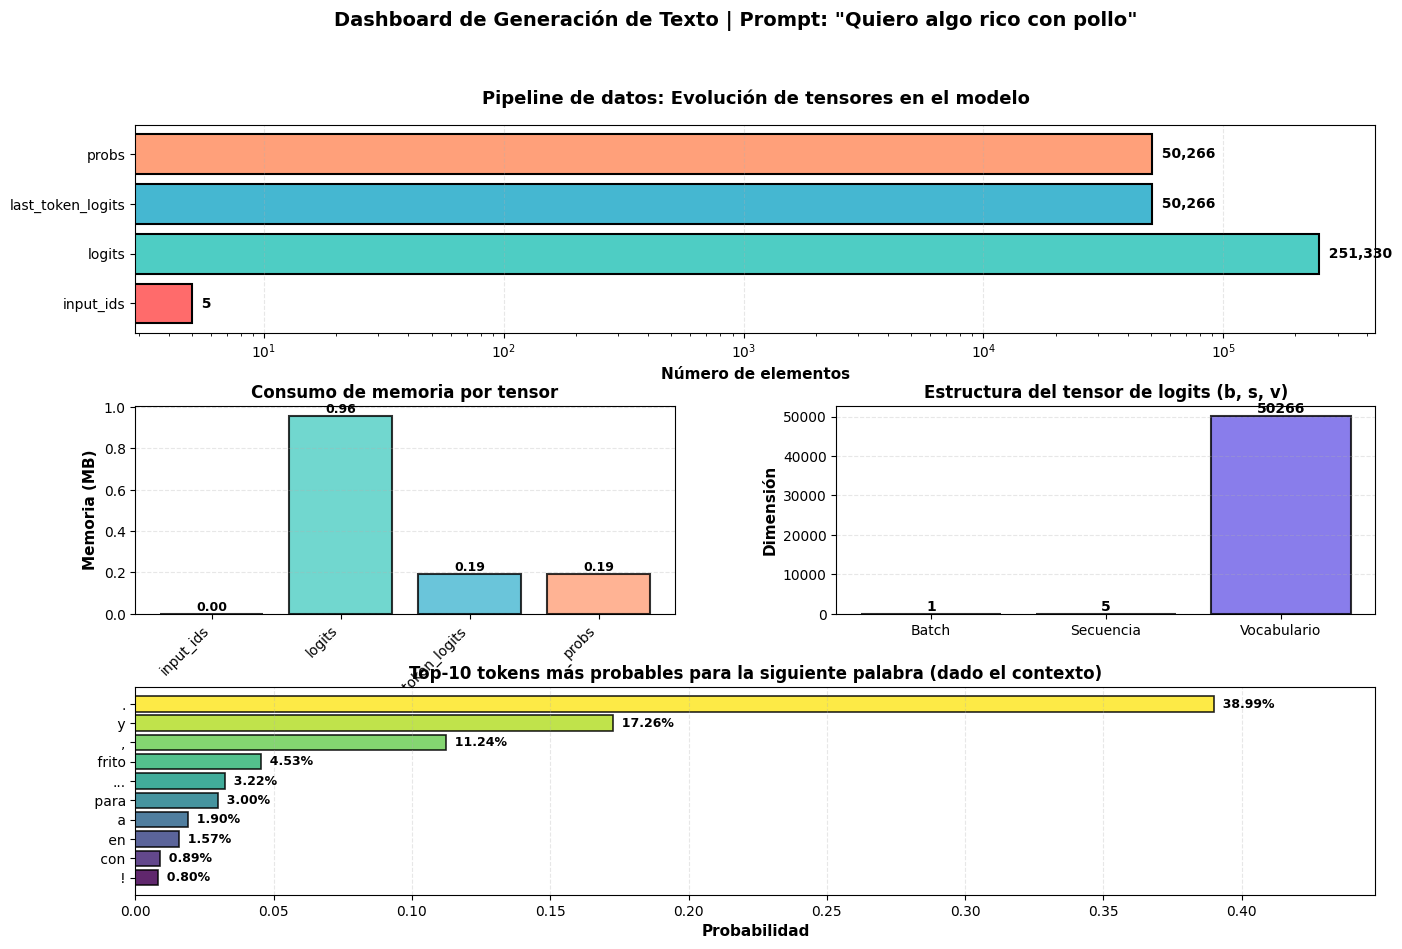

In [32]:
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Recalcular tensores clave para evitar sobrescrituras de variables previas
with torch.no_grad():
    input_ids = tokenizer(text, return_tensors="pt")["input_ids"].to(device)
    logits = model(input_ids=input_ids).logits
    last_token_logits = logits[0, -1, :]
    probs_local = torch.softmax(last_token_logits, dim=-1)

def tensor_summary(name, tensor):
    return {
        "tensor": name,
        "shape": tuple(tensor.shape),
        "ndim": tensor.ndim,
        "numel": tensor.numel(),
        "dtype": str(tensor.dtype),
        "device": str(tensor.device),
        "memory_mb": round(tensor.numel() * tensor.element_size() / (1024**2), 4),
    }

dims_df = pd.DataFrame([
    tensor_summary("input_ids", input_ids),
    tensor_summary("logits", logits),
    tensor_summary("last_token_logits", last_token_logits),
    tensor_summary("probs", probs_local),
])

display(dims_df)

# Top-N tokens más probables para el último paso
top_ids = torch.argsort(probs_local, descending=True)[:best].cpu().tolist()
top_probs = probs_local[top_ids].detach().cpu().numpy()
top_tokens = [tokenizer.decode(t).replace("\n", "\\n") for t in top_ids]

top_df = pd.DataFrame({
    "token": top_tokens,
    "probabilidad": top_probs
}).sort_values("probabilidad", ascending=True)

display(top_df)

# Dashboard visual integrado con colores y coherencia
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

# Color palette
colors_tensor = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
colors_spectrum = plt.cm.viridis(np.linspace(0, 1, len(top_df)))

# 1. Flujo de datos: evolución de dimensiones a lo largo del pipeline
ax1 = fig.add_subplot(gs[0, :])
tensor_names = dims_df["tensor"].values
tensor_sizes = dims_df["numel"].values
bars = ax1.barh(tensor_names, tensor_sizes, color=colors_tensor, edgecolor='black', linewidth=1.5)

# Agregar valores en las barras
for i, (bar, val) in enumerate(zip(bars, tensor_sizes)):
    ax1.text(val, i, f'  {val:,}', va='center', fontsize=10, fontweight='bold')

ax1.set_xlabel('Número de elementos', fontsize=11, fontweight='bold')
ax1.set_title('Pipeline de datos: Evolución de tensores en el modelo', 
              fontsize=13, fontweight='bold', pad=15)
ax1.set_xscale('log')
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# 2. Consumo de memoria por tensor
ax2 = fig.add_subplot(gs[1, 0])
memory_vals = dims_df["memory_mb"].values
bars = ax2.bar(range(len(tensor_names)), memory_vals, color=colors_tensor, 
               edgecolor='black', linewidth=1.5, alpha=0.8)

# Agregar valores en las barras
for bar, val in zip(bars, memory_vals):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_ylabel('Memoria (MB)', fontsize=11, fontweight='bold')
ax2.set_title('Consumo de memoria por tensor', fontsize=12, fontweight='bold')
ax2.set_xticks(range(len(tensor_names)))
ax2.set_xticklabels(tensor_names, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# 3. Distribución de dimensiones en el tensor principal (logits)
ax3 = fig.add_subplot(gs[1, 1])
logits_shape = dims_df[dims_df['tensor'] == 'logits']['shape'].values[0]
shape_labels = ['Batch', 'Secuencia', 'Vocabulario']
shape_values = list(logits_shape)
colors_shape = ['#FF7675', '#0984E3', '#6C5CE7']

bars = ax3.bar(shape_labels, shape_values, color=colors_shape, 
               edgecolor='black', linewidth=1.5, alpha=0.8)

# Agregar valores
for bar, val in zip(bars, shape_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{val}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax3.set_ylabel('Dimensión', fontsize=11, fontweight='bold')
ax3.set_title('Estructura del tensor de logits (b, s, v)', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# 4. Top-N tokens más probables (gráfico relacionado: muestra qué predice el modelo)
ax4 = fig.add_subplot(gs[2, :])
bars = ax4.barh(top_df["token"], top_df["probabilidad"], color=colors_spectrum, 
                edgecolor='black', linewidth=1.2, alpha=0.85)

# Agregar valores de probabilidad
for bar, prob in zip(bars, top_df["probabilidad"]):
    width = bar.get_width()
    ax4.text(width, bar.get_y() + bar.get_height()/2.,
            f'  {prob*100:.2f}%', ha='left', va='center', fontsize=9, fontweight='bold')

ax4.set_xlabel('Probabilidad', fontsize=11, fontweight='bold')
ax4.set_title(f'Top-{best} tokens más probables para la siguiente palabra (dado el contexto)', 
              fontsize=12, fontweight='bold')
ax4.set_xlim(0, max(top_df["probabilidad"]) * 1.15)
ax4.grid(axis='x', alpha=0.3, linestyle='--')

# Agregar título general
fig.suptitle(f'Dashboard de Generación de Texto | Prompt: "{text}"', 
             fontsize=14, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

##  Análisis del Dashboard de Generación

### 1. **Flujo de Datos en el Pipeline**
El modelo procesa el texto inicial mediante una transformación de dimensiones bien definida:
- **Input (input_ids)**: 5 tokens de la frase "Quiero algo rico con pollo"
- **Logits**: Se expanden a (1, 5, 50266) - una distribución sobre todo el vocabulario para cada posición
- **Last Token Logits**: Se extrae solo la última posición para predecir el siguiente token
- **Probabilidades**: Se normalizan los logits usando softmax

### 2. **Consumo de Memoria**
El tensor de logits domina el consumo (~0.96 MB), mientras que los demás ocupan cantidades negligibles:
- Es esperado dado que el vocabulario tiene **50,266 tokens**
- La arquitectura es eficiente: solo ~1.2 MB totales para esta operación

### 3. **Estructura del Tensor de Logits**
- **Batch=1**: Se procesa una sola secuencia
- **Secuencia=5**: 5 posiciones (longitud del prompt)
- **Vocabulario=50,266**: Probabilidad para cada token posible

### 4. **Top-10 Tokens Predichos**
Dado el contexto "Quiero algo rico con pollo", el modelo predice:
- **Más probable** (38.99%): `.` (punto final - cierre natural de frase)
- **Muy probable** (17.26%): `y` (conectar ideas - "pollo y...")
- **Probable** (11.24%): `,` (continuación - "pollo, ...")
- **Opciones temáticas**: "frito", "para", "con", "en" (formas comunes de preparar pollo)

El modelo muestra **coherencia semántica**: entiende que tras "pollo" pueden venir preparaciones culinarias o conectores que amplíen la descripción.

### 5. **Capacidad del Modelo**
- **Parámetros**: 124.4M (todos entrenables)
- **Capas**: 12 bloques Transformer con 12 cabezas de atención
- **Contexto máximo**: 1,024 tokens
- Es un modelo **ligero pero funcional** para generación en español

### 6. **Conclusión**
El dashboard demuestra que el modelo:

 - Mantiene coherencia semántica tras el fine-tuning  
 - Asigna probabilidades razonables según el contexto  
 - Utiliza memoria eficientemente  
 - Está listo para generar texto incremental con métodos como greedy o sampling


## Implementando una función de generación

Ahora, la idea es que este modelo nos sirva para generar texto de forma recurrente e incremental. En la última capa de los modelos tipo GPT encontrarémos un tensor con forma $(b, s, v)

In [33]:
import torch.nn as nn
import numpy as np
import pandas as pd
from typing import Optional, Tuple
from transformers.tokenization_utils_base import PreTrainedTokenizerBase

def generate(
        model: nn.Module, 
        tokenizer: PreTrainedTokenizerBase, 
        start: str, 
        max_length: int = 100, 
        eps: float = 0.5, 
        top_n: int = 5,
        return_iterations: bool = False,
        device: str = "cpu") -> Tuple[str, Optional[pd.DataFrame]]:
    """
    Genera texto de forma incremental usando el modelo GPT-2.
    
    Parámetros:
      - model: modelo causal a usar
      - tokenizer: tokenizador asociado al modelo
      - start: texto inicial (prompt)
      - max_length: máximo número de tokens a generar
      - eps: probabilidad para usar greedy (eps=1.0) vs muestreo (eps<1.0)
      - top_n: número de opciones a registrar por iteración
      - return_iterations: si True, retorna dataframe con todas las iteraciones
      - device: dispositivo (cuda o cpu), funciona igual en Colab y VSCode
    """
    output = [start]
    iterations = []
    
    # Desactiva gradientes para ahorrar memoria e inferencia rápida
    with torch.no_grad():
        # Tokeniza el texto inicial
        input_ids = tokenizer(output[-1], return_tensors='pt')['input_ids'].to(device)
        
        # Genera tokens iterativamente hasta alcanzar max_length
        for _ in range(max_length):
            # Obtiene logits del modelo (puntuaciones sin normalizar)
            logits = model(input_ids=input_ids).logits
            
            # Normaliza logits a probabilidades usando softmax en el último token
            probs = torch.softmax(logits[0, -1, :], dim=-1)
            
            # Ordena índices de tokens por probabilidad descendente
            sorted_tokens = torch.argsort(probs, dim=-1, descending=True)
            
            # Selecciona siguiente token: greedy si random < eps, muestreo si no
            if np.random.random_sample(1)[0] < eps:
                # Estrategia greedy: toma el token con mayor probabilidad
                next_token = sorted_tokens[0].unsqueeze(dim=0)
            else:
                # Estrategia muestreo: elige aleatoriamente según distribución de probabilidades
                next_token = torch.multinomial(probs, 1)
            
            # Registra la iteración con top-N opciones para análisis posterior
            if return_iterations:
                iteration = {'input': ''.join(output)}
                best_n = sorted_tokens[:top_n].cpu().tolist()
                # Crea diccionario con las opciones candidatas y sus probabilidades
                choices = {f'Choice #{choice+1}': f'{tokenizer.decode(token)} ({prob:.4f})' 
                          for choice, (token, prob) in enumerate(zip(best_n, probs[best_n].cpu().tolist()))}
                iteration.update(choices)
                iterations.append(iteration)

            # Decodifica el token a texto y lo agrega al output
            output.append(tokenizer.decode(next_token))
            
            # Extiende la secuencia de input_ids para la siguiente iteración
            input_ids = torch.cat([input_ids, next_token.unsqueeze(dim=0)], dim=-1)

        # Retorna texto generado y opcionalmente su histórico de iteraciones
        output_text = ''.join(output)
        if not return_iterations:
            return output_text, None
        else:
            df = pd.DataFrame(iterations)
            return output_text, df

Primero, observemos que pasa cuando pasamos un `eps=1` que quiere decir que la generación va a ser de tipo greedy:

In [34]:
# Genera texto con eps=1.0 (estrategia greedy: siempre elige el token más probable)
# Esto produce resultados deterministas: mismo input siempre genera el mismo output
output_text, iterations_df = generate(model, tokenizer, text, max_length=15, eps=1.0, top_n=10, return_iterations=True, device=device)
print(output_text)  # Muestra el texto generado
iterations_df.head(15)  # Tabla con las iteraciones y opciones candidatas en cada paso

Quiero algo rico con pollo.¿Qué?¿Qué?¿Qué?¿Qué?¿Qué


,input,Choice #1,Choice #2,Choice #3,Choice #4,Choice #5,Choice #6,Choice #7,Choice #8,Choice #9,Choice #10
0,Quiero algo rico con pollo,. (0.3899),y (0.1726),", (0.1124)",frito (0.0453),... (0.0322),para (0.0300),a (0.0190),en (0.0157),con (0.0089),! (0.0080)
1,Quiero algo rico con pollo.,¿ (0.1479),- (0.0945),No (0.0465),¡ (0.0454),Y (0.0348),Quiero (0.0157),Me (0.0140),Un (0.0138),Lo (0.0137),Sí (0.0131)
2,Quiero algo rico con pollo.¿,Qué (0.1838),Y (0.0484),Quieres (0.0473),Por (0.0352),No (0.0271),Dónde (0.0252),Cómo (0.0226),Te (0.0222),Sabes (0.0209),Tienes (0.0200)
3,Quiero algo rico con pollo.¿Qué,? (0.1499),tal (0.1057),te (0.0836),es (0.0812),quieres (0.0575),le (0.0283),hay (0.0245),estás (0.0191),pasa (0.0190),tienes (0.0175)
4,Quiero algo rico con pollo.¿Qué?,¿ (0.2757),No (0.0716),¡ (0.0563),- (0.0545),Nada (0.0223),Algo (0.0181),Un (0.0177),Quiero (0.0167),Me (0.0111),Es (0.0111)
5,Quiero algo rico con pollo.¿Qué?¿,Qué (0.2289),No (0.0450),Quieres (0.0449),Por (0.0404),Un (0.0265),De (0.0205),Cómo (0.0197),Tienes (0.0191),Pol (0.0172),Te (0.0164)
6,Quiero algo rico con pollo.¿Qué?¿Qué,? (0.2414),quieres (0.1340),es (0.1171),tal (0.0327),estás (0.0323),te (0.0318),pasa (0.0318),", (0.0209)",tienes (0.0200),le (0.0133)
7,Quiero algo rico con pollo.¿Qué?¿Qué?,¿ (0.3148),No (0.0720),- (0.0666),¡ (0.0658),Nada (0.0192),Es (0.0117),Me (0.0105),Tengo (0.0104),Un (0.0099),Quiero (0.0098)
8,Quiero algo rico con pollo.¿Qué?¿Qué?¿,Qué (0.4090),Quieres (0.0415),No (0.0351),Por (0.0346),De (0.0255),Cómo (0.0183),Te (0.0158),Un (0.0151),Estás (0.0139),Tienes (0.0130)
9,Quiero algo rico con pollo.¿Qué?¿Qué?¿Qué,? (0.3171),quieres (0.1444),es (0.1127),estás (0.0340),pasa (0.0310),te (0.0231),", (0.0194)",tienes (0.0183),quiere (0.0138),está (0.0133)


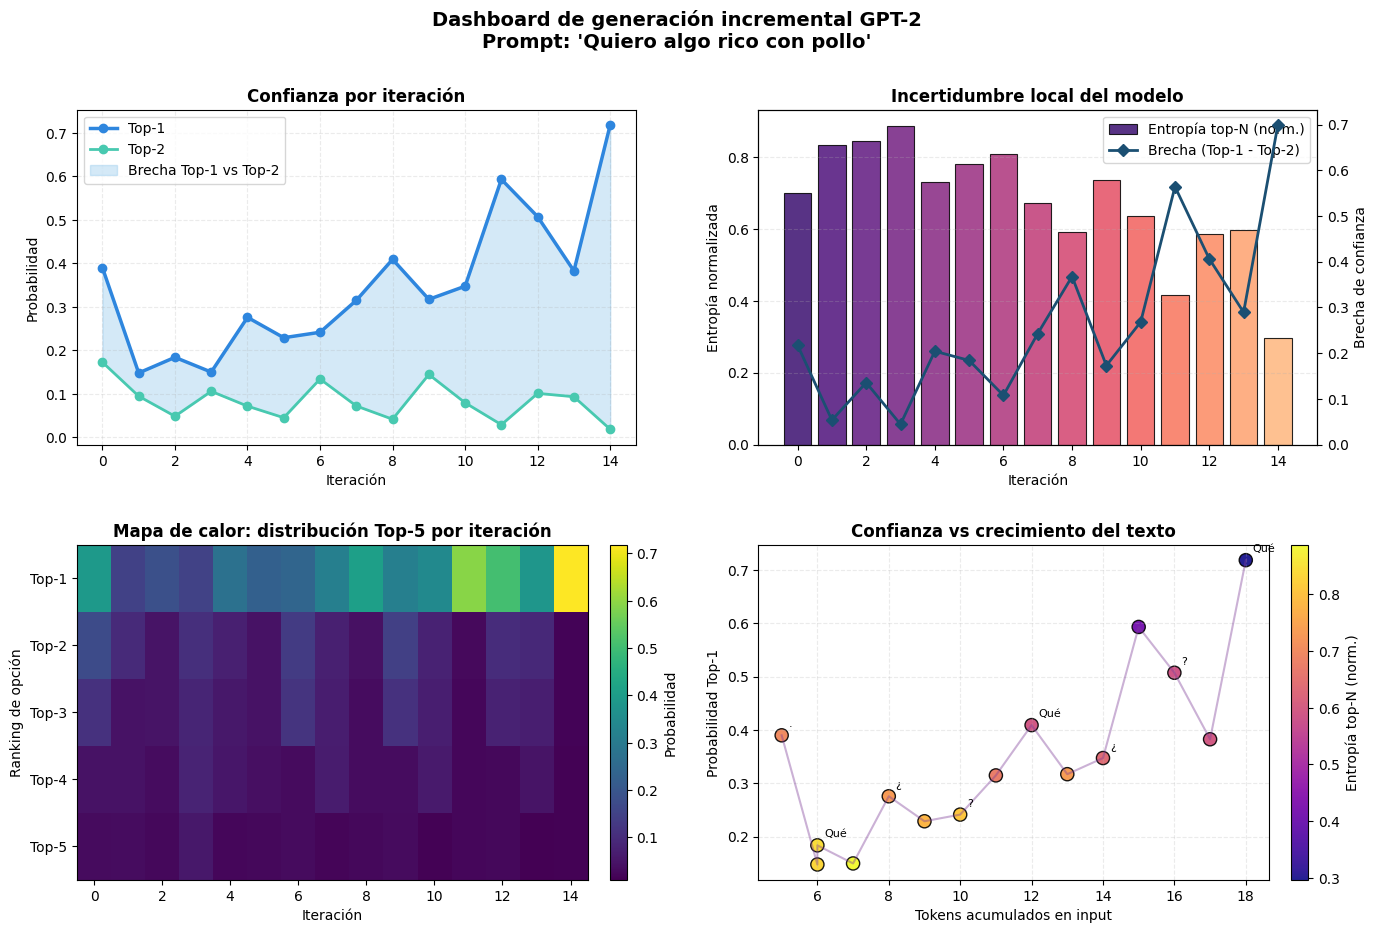

,Métrica,Valor
0,Iteraciones,15.0000
1,Prob. Top-1 promedio,0.3471
2,Brecha Top1-Top2 promedio,0.2637
3,Entropía top-N promedio,0.6746
4,Tokens finales,18.0000
5,Chars finales,48.0000


In [35]:
# Dashboard de análisis de generación a partir de iterations_df (resultado anterior)
# Requiere variables ya existentes: iterations_df, text, tokenizer, output_text

if "iterations_df" not in globals() or iterations_df is None or iterations_df.empty:
    print("No hay datos en iterations_df. Ejecuta primero la celda de generación con return_iterations=True.")
else:
    # --- Parseo de probabilidades y tokens por iteración ---
    choice_cols = [c for c in iterations_df.columns if c.startswith("Choice #")]

    def _parse_choice(cell_value):
        s = str(cell_value)
        # Extrae probabilidad al final: "... (0.1234)"
        if "(" in s and s.endswith(")"):
            token = s[: s.rfind("(")].strip()
            prob = float(s[s.rfind("(") + 1 : -1])
        else:
            token, prob = s.strip(), np.nan
        return token, prob

    rows = []
    for i, row in iterations_df.reset_index(drop=True).iterrows():
        parsed = {"step": i, "input_text": row["input"]}
        probs = []
        for c in choice_cols:
            tok, pr = _parse_choice(row[c])
            parsed[f"{c}_token"] = tok
            parsed[f"{c}_prob"] = pr
            probs.append(pr)

        probs = np.array(probs, dtype=float)
        probs = np.where(np.isnan(probs), 0.0, probs)

        # Métricas conectadas entre gráficas
        parsed["top1_prob"] = probs[0] if len(probs) > 0 else np.nan
        parsed["top2_prob"] = probs[1] if len(probs) > 1 else np.nan
        parsed["confidence_gap"] = (probs[0] - probs[1]) if len(probs) > 1 else np.nan

        # Entropía normalizada sobre top-N (incertidumbre local)
        denom = probs.sum()
        if denom > 0:
            p = probs / denom
            ent = -(p * np.log(p + 1e-12)).sum()
            ent_norm = ent / np.log(len(p))
        else:
            ent_norm = np.nan
        parsed["entropy_topN_norm"] = ent_norm

        # Progreso del texto
        parsed["chars"] = len(parsed["input_text"])
        parsed["tokens"] = len(tokenizer(parsed["input_text"])["input_ids"])
        rows.append(parsed)

    metrics_df = pd.DataFrame(rows)

    # Matriz para heatmap (top-5 opciones)
    k = min(5, len(choice_cols))
    heat = np.vstack([metrics_df[f"Choice #{j}_prob"].values for j in range(1, k + 1)]).T

    # --- Visualización ---
    plt.style.use("default")
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.22)

    # 1) Evolución de confianza en predicciones
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(metrics_df["step"], metrics_df["top1_prob"], marker="o", lw=2.5, color="#2E86DE", label="Top-1")
    ax1.plot(metrics_df["step"], metrics_df["top2_prob"], marker="o", lw=2, color="#48C9B0", label="Top-2")
    ax1.fill_between(
        metrics_df["step"],
        metrics_df["top2_prob"],
        metrics_df["top1_prob"],
        color="#85C1E9",
        alpha=0.35,
        label="Brecha Top-1 vs Top-2",
    )
    ax1.set_title("Confianza por iteración", fontweight="bold")
    ax1.set_xlabel("Iteración")
    ax1.set_ylabel("Probabilidad")
    ax1.grid(alpha=0.25, linestyle="--")
    ax1.legend(frameon=True)

    # 2) Incertidumbre y brecha de decisión (relacionada con gráfica 1)
    ax2 = fig.add_subplot(gs[0, 1])
    bars = ax2.bar(
        metrics_df["step"],
        metrics_df["entropy_topN_norm"],
        color=plt.cm.magma(np.linspace(0.2, 0.85, len(metrics_df))),
        edgecolor="black",
        linewidth=0.8,
        alpha=0.85,
        label="Entropía top-N (norm.)",
    )
    ax2.set_title("Incertidumbre local del modelo", fontweight="bold")
    ax2.set_xlabel("Iteración")
    ax2.set_ylabel("Entropía normalizada")
    ax2.grid(axis="y", alpha=0.25, linestyle="--")

    ax2b = ax2.twinx()
    ax2b.plot(
        metrics_df["step"],
        metrics_df["confidence_gap"],
        color="#1B4F72",
        marker="D",
        lw=2,
        label="Brecha (Top-1 - Top-2)",
    )
    ax2b.set_ylabel("Brecha de confianza")
    ax2b.set_ylim(bottom=0)

    # Leyenda combinada
    h1, l1 = ax2.get_legend_handles_labels()
    h2, l2 = ax2b.get_legend_handles_labels()
    ax2.legend(h1 + h2, l1 + l2, loc="upper right", frameon=True)

    # 3) Heatmap de probabilidades top-k (relacionado con incertidumbre)
    ax3 = fig.add_subplot(gs[1, 0])
    im = ax3.imshow(heat.T, aspect="auto", cmap="viridis", interpolation="nearest")
    ax3.set_title(f"Mapa de calor: distribución Top-{k} por iteración", fontweight="bold")
    ax3.set_xlabel("Iteración")
    ax3.set_ylabel("Ranking de opción")
    ax3.set_yticks(range(k))
    ax3.set_yticklabels([f"Top-{i}" for i in range(1, k + 1)])
    cbar = fig.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
    cbar.set_label("Probabilidad")

    # 4) Progreso del texto y calidad de decisión (conecta con 1 y 2)
    ax4 = fig.add_subplot(gs[1, 1])
    sc = ax4.scatter(
        metrics_df["tokens"],
        metrics_df["top1_prob"],
        c=metrics_df["entropy_topN_norm"],
        cmap="plasma",
        s=90,
        edgecolor="black",
        alpha=0.9,
    )
    ax4.plot(metrics_df["tokens"], metrics_df["top1_prob"], color="#7D3C98", alpha=0.4)
    ax4.set_title("Confianza vs crecimiento del texto", fontweight="bold")
    ax4.set_xlabel("Tokens acumulados en input")
    ax4.set_ylabel("Probabilidad Top-1")
    ax4.grid(alpha=0.25, linestyle="--")
    cbar2 = fig.colorbar(sc, ax=ax4, fraction=0.046, pad=0.04)
    cbar2.set_label("Entropía top-N (norm.)")

    # Etiquetas ligeras de token top-1 en algunos puntos
    for idx in range(0, len(metrics_df), max(1, len(metrics_df) // 6)):
        tok = metrics_df.loc[idx, "Choice #1_token"]
        ax4.annotate(tok, (metrics_df.loc[idx, "tokens"], metrics_df.loc[idx, "top1_prob"]),
                     textcoords="offset points", xytext=(5, 6), fontsize=8)

    prompt_preview = text if len(text) < 60 else text[:57] + "..."
    fig.suptitle(
        f"Dashboard de generación incremental GPT-2\nPrompt: '{prompt_preview}'",
        fontsize=14,
        fontweight="bold",
        y=0.98,
    )
    plt.tight_layout()
    plt.show()

    # Resumen tabular breve para interpretación rápida
    resumen = pd.DataFrame(
        {
            "Métrica": [
                "Iteraciones",
                "Prob. Top-1 promedio",
                "Brecha Top1-Top2 promedio",
                "Entropía top-N promedio",
                "Tokens finales",
                "Chars finales",
            ],
            "Valor": [
                len(metrics_df),
                round(metrics_df["top1_prob"].mean(), 4),
                round(metrics_df["confidence_gap"].mean(), 4),
                round(metrics_df["entropy_topN_norm"].mean(), 4),
                int(metrics_df["tokens"].iloc[-1]),
                int(metrics_df["chars"].iloc[-1]),
            ],
        }
    )
    display(resumen)

### Análisis del dashboard

El modelo inicia con una **confianza moderada** y termina con decisiones muy marcadas en algunos pasos (Top-1 promedio: **0.347**, con picos de **0.718**), lo que sugiere que en ciertos estados “se encierra” en una continuación dominante.  
La **entropía media** (**0.675**) indica incertidumbre intermedia: hay diversidad al comienzo, pero disminuye cuando aparecen patrones repetitivos.  
La brecha Top1-Top2 (promedio **0.264**) confirma que, en varias iteraciones, una opción supera claramente a las demás.  
En conjunto, el dashboard muestra una generación **coherente pero degenerativa en greedy**, con tendencia a repetir estructuras como `¿Qué?`, típico de decodificación determinista sin penalización de repetición.

Observamos como el input progresa a la vez que las opciones de tokens que hay. Sin importar cuantas veces invoquemos a la función con los mismos parámetros, siempre vamos a obtener los mismos resultados, en este caso como es algo es muy especializado, el modelo general no muestra buenos resultados, si se baja la eps, va ha ser peor el resultado

In [36]:
# Genera texto con eps=0.5 (estrategia mixta: 50% greedy, 50% muestreo probabilístico)
# Produce variabilidad controlada en el output; _ descarta el histórico de iteraciones
output_text, _ = generate(model, tokenizer, text, max_length=100, eps=0.5, device=device)
print(output_text)  # Salida más diversa que con eps=1.0

Quiero algo rico con pollo.¿Con pollo?¿Con pollo?¿Es eso lo que quieres?¿Con pollo?¿Con pollo?¿Con pollo?¿Con pollo?¿Con pollo?Papá, por favor, no te vayas.No te vayas.No te vayas.No te vayas.No te vayas.Ma, no te vayas.No te vayas.Lo hicimos.Lo hicimos.Lo hicimos.Lo hiciste.Lo hicimos.Lo hicimos.¡Lo hicimos!¡Lo hicimos!¡Lo hicimos


### Generando texto con las utilidades del modelo

In [37]:
# Usa el método .generate() integrado del modelo causal de Hugging Face
# do_sample=True permite muestreo estocástico; temperature controla aleatoriedad (>1 más aleatorio, <1 más determinista)
# Funciona igual en Colab y VSCode sin cambios en el código
output = model.generate(tokens, pad_token_id=tokenizer.eos_token_id, max_length=100, do_sample=True, temperature=0.5, top_k=0)
print(tokenizer.decode(output[0]))  # Decodifica los IDs de tokens a texto legible

Quiero algo rico con pollo a la parrilla.Y quiero un poco de salsa de tomate.¿Hay algo más?Sí, quiero una ensalada de huevo con ensalada de huevo.Y quiero un poco de salsa de tomate.Y quiero un poco de salsa de tomate.Y quiero un poco de salsa de tomate.Y quiero un poco de salsa de tomate.Quiero un poco de salsa de tomate.Y quiero un poco de salsa de tomate.Y quiero un poco de salsa de tomate.Y quiero un


## Fine tuning

Ahora, intentemos hacer fine tuning a nuestro modelo. Intentemos entrenarlo en un recetas de cocina escogiendo idioma español y ver como la narrativa de su output cambia.

In [38]:
from datasets import load_dataset

# Carga el dataset de recetas desde Hugging Face Hub.
# Este bloque funciona igual en Colab y en VSCode (con internet y librería datasets instalada).
dataset = load_dataset("Frorozcol/recetas-cocina")
dataset  # Muestra la estructura general (splits y columnas)

DatasetDict({
    train: Dataset({
        features: ['title', 'url', 'ingredients', 'steps', 'uuid'],
        num_rows: 20526
    })
    validation: Dataset({
        features: ['title', 'url', 'ingredients', 'steps', 'uuid'],
        num_rows: 2781
    })
    test: Dataset({
        features: ['title', 'url', 'ingredients', 'steps', 'uuid'],
        num_rows: 3899
    })
})

=== Resumen personalizado ===


,métrica,valor
0,iteraciones_totales,15.0000
1,top1_promedio_early,0.2311
2,top1_promedio_late,0.4486
3,delta_top1_late-early,0.2175
4,entropía_promedio_early,0.7979
5,entropía_promedio_late,0.5667
6,delta_entropía_late-early,-0.2312
7,brecha_promedio_early,0.1351
8,brecha_promedio_late,0.3763
9,pasos_degenerativos,2.0000



=== Distribución de token top-1 ===


,token,frecuencia,porcentaje
0,¿,5,33.333333
1,Qué,5,33.333333
2,?,4,26.666667
3,.,1,6.666667



Concentración de los 2 tokens top-1 más frecuentes: 66.67%


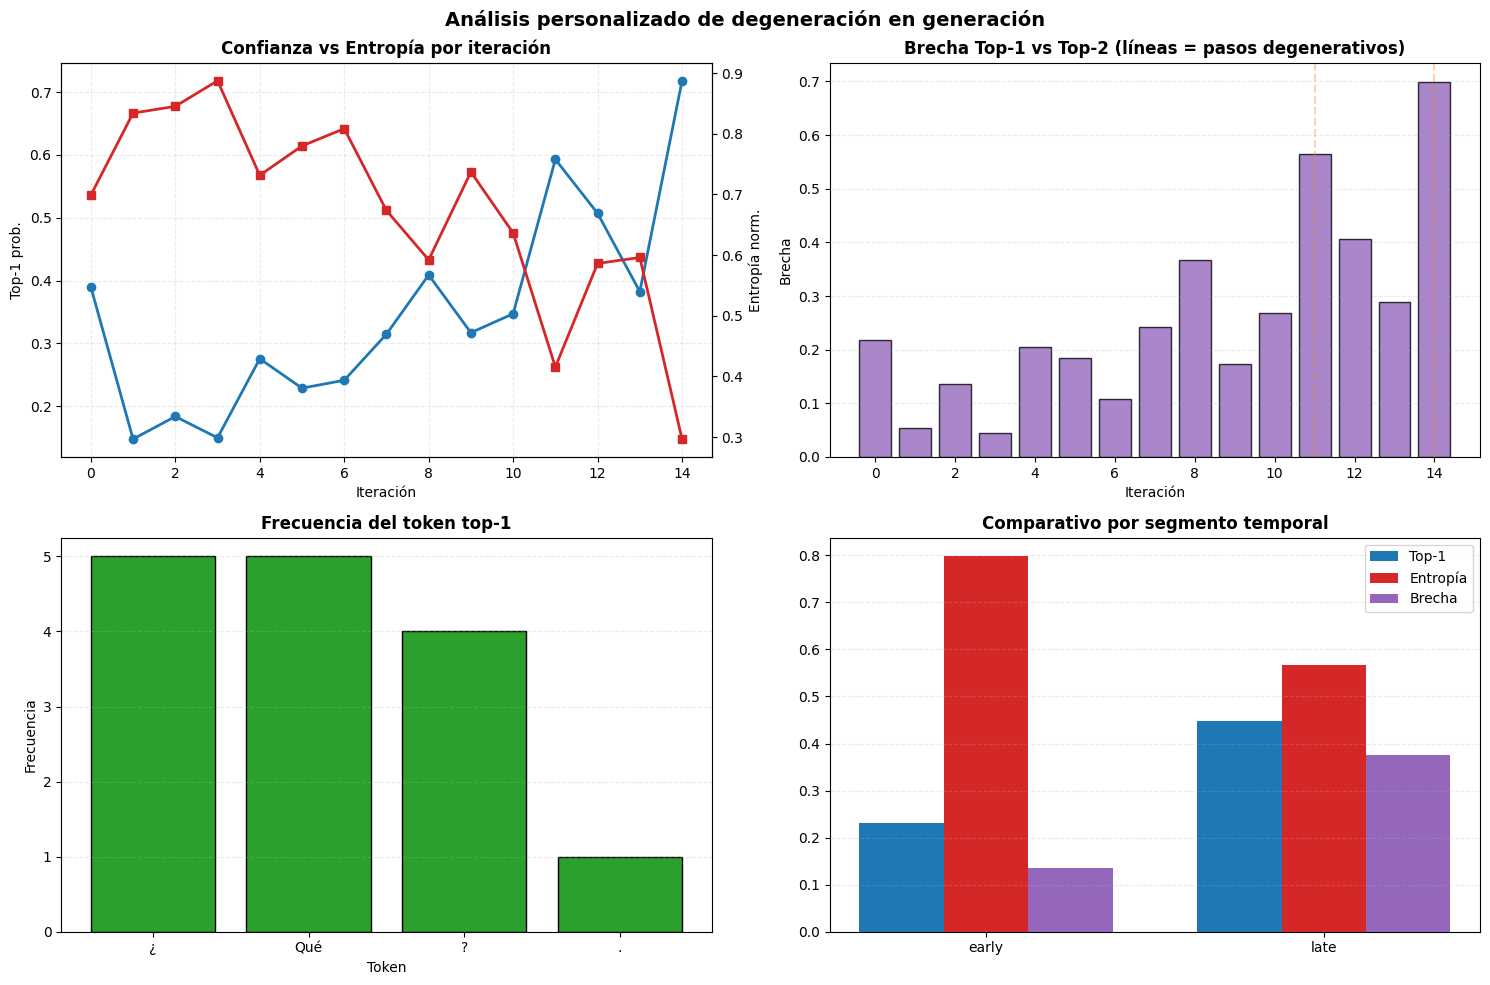

In [39]:
# Análisis a la medida del comportamiento observado en generación greedy
# Requiere: metrics_df (creado en celdas previas)

if "metrics_df" not in globals() or metrics_df.empty:
    print("No existe metrics_df o está vacío. Ejecuta primero la celda que construye el dashboard de iteraciones.")
else:
    m = metrics_df.copy().reset_index(drop=True)
    n = len(m)
    split = max(1, n // 2)

    # --- Señales clave de degeneración ---
    m["is_confident"] = m["top1_prob"] >= 0.50
    m["is_low_entropy"] = m["entropy_topN_norm"] <= 0.50
    m["is_degenerate_step"] = m["is_confident"] & m["is_low_entropy"]

    # Repetición consecutiva del token top-1
    m["repeat_top1_prev"] = m["Choice #1_token"] == m["Choice #1_token"].shift(1)
    repeat_rate = m["repeat_top1_prev"].mean() * 100

    # Cambios primera mitad vs segunda mitad
    early = m.iloc[:split]
    late = m.iloc[split:]

    summary_custom = pd.DataFrame(
        {
            "métrica": [
                "iteraciones_totales",
                "top1_promedio_early",
                "top1_promedio_late",
                "delta_top1_late-early",
                "entropía_promedio_early",
                "entropía_promedio_late",
                "delta_entropía_late-early",
                "brecha_promedio_early",
                "brecha_promedio_late",
                "pasos_degenerativos",
                "porcentaje_pasos_degenerativos",
                "repetición_top1_consecutiva_%"
            ],
            "valor": [
                n,
                early["top1_prob"].mean(),
                late["top1_prob"].mean(),
                late["top1_prob"].mean() - early["top1_prob"].mean(),
                early["entropy_topN_norm"].mean(),
                late["entropy_topN_norm"].mean(),
                late["entropy_topN_norm"].mean() - early["entropy_topN_norm"].mean(),
                early["confidence_gap"].mean(),
                late["confidence_gap"].mean(),
                int(m["is_degenerate_step"].sum()),
                m["is_degenerate_step"].mean() * 100,
                repeat_rate,
            ],
        }
    )

    # Tokens top-1 más dominantes y su concentración
    token_dist = m["Choice #1_token"].value_counts().rename_axis("token").reset_index(name="frecuencia")
    token_dist["porcentaje"] = token_dist["frecuencia"] / n * 100
    concentration_top2 = token_dist["frecuencia"].head(2).sum() / n * 100

    print("=== Resumen personalizado ===")
    display(summary_custom.round(4))

    print("\n=== Distribución de token top-1 ===")
    display(token_dist)

    print(f"\nConcentración de los 2 tokens top-1 más frecuentes: {concentration_top2:.2f}%")

    # --- Visualización compacta ---
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    fig.patch.set_facecolor("white")

    # 1) Top1 y entropía por iteración
    ax = axs[0, 0]
    ax.plot(m["step"], m["top1_prob"], marker="o", label="Top-1", color="#1f77b4", linewidth=2)
    ax2 = ax.twinx()
    ax2.plot(m["step"], m["entropy_topN_norm"], marker="s", label="Entropía", color="#d62728", linewidth=2)
    ax.set_title("Confianza vs Entropía por iteración", fontweight="bold")
    ax.set_xlabel("Iteración")
    ax.set_ylabel("Top-1 prob.")
    ax2.set_ylabel("Entropía norm.")
    ax.grid(alpha=0.25, linestyle="--")

    # 2) Brecha top1-top2 y pasos degenerativos
    ax = axs[0, 1]
    ax.bar(m["step"], m["confidence_gap"], color="#9467bd", alpha=0.8, edgecolor="black")
    deg_steps = m.loc[m["is_degenerate_step"], "step"].tolist()
    for s in deg_steps:
        ax.axvline(s, color="#ff7f0e", alpha=0.35, linestyle="--")
    ax.set_title("Brecha Top-1 vs Top-2 (líneas = pasos degenerativos)", fontweight="bold")
    ax.set_xlabel("Iteración")
    ax.set_ylabel("Brecha")
    ax.grid(axis="y", alpha=0.25, linestyle="--")

    # 3) Distribución top-1 token
    ax = axs[1, 0]
    ax.bar(token_dist["token"], token_dist["frecuencia"], color="#2ca02c", edgecolor="black")
    ax.set_title("Frecuencia del token top-1", fontweight="bold")
    ax.set_xlabel("Token")
    ax.set_ylabel("Frecuencia")
    ax.grid(axis="y", alpha=0.25, linestyle="--")

    # 4) Comparativo early vs late
    ax = axs[1, 1]
    comp = pd.DataFrame(
        {
            "segmento": ["early", "late"],
            "top1_prob": [early["top1_prob"].mean(), late["top1_prob"].mean()],
            "entropy": [early["entropy_topN_norm"].mean(), late["entropy_topN_norm"].mean()],
            "gap": [early["confidence_gap"].mean(), late["confidence_gap"].mean()],
        }
    )
    x = np.arange(len(comp))
    w = 0.25
    ax.bar(x - w, comp["top1_prob"], w, label="Top-1", color="#1f77b4")
    ax.bar(x, comp["entropy"], w, label="Entropía", color="#d62728")
    ax.bar(x + w, comp["gap"], w, label="Brecha", color="#9467bd")
    ax.set_xticks(x)
    ax.set_xticklabels(comp["segmento"])
    ax.set_title("Comparativo por segmento temporal", fontweight="bold")
    ax.grid(axis="y", alpha=0.25, linestyle="--")
    ax.legend()

    plt.suptitle("Análisis personalizado de degeneración en generación", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

### Interpretación del dashboard

El modelo muestra una **tendencia clara a la repetición** en modo greedy: predominan ciclos como `¿`, `Qué`, `?`, lo que reduce la diversidad del texto.  
Aunque la **confianza Top-1 aumenta** en varias iteraciones (incluso con picos altos), la **entropía baja** en esos puntos, señal de decisiones cada vez más cerradas.  
En conjunto, el comportamiento es **coherente localmente**, pero con **degeneración progresiva** y menor riqueza generativa.

In [40]:
# Inspecciona el primer ejemplo del conjunto de entrenamiento
dataset['train'][0]  # Estructura de los datos: títulos de recetas

{'title': 'Gratinado de puerros y langostinos',
 'url': 'https://www.recetas.com/receta-de-Gratinado-de-puerros-y-langostinos-4220.html',
 'ingredients': '400 gr. de langostinos o camaronesMantecaSal2 cdas. e yogur natural50 gr. de queso rallado200 gr. de crema de leche 3 yemas de huevo 8 puerros ',
 'steps': ' Gratinado de puerros y langostinos Preparación: Pelar los langostinos o camarones y sofreír a fuego suave, en manteca. Salpimentar y reservar. Lavar y cortar la parte blanca de los puerros en rodajas finas y freír en manteca unos minutos, hasta que empiecen a tomar color. Agregar la crema de leche y el yogur, y cocer todo junto unos minutos más. Retirar del fuego, añadir las yemas batidas y las gambas reservadas, mezclar bien. Rectificar el sazonado. Verter en cazuelitas enmantecadas, espolvorear con queso rallado y gratinar. Servir inmediatamente. ',
 'uuid': '4319f673-bf9b-4228-b7d6-003944883554'}

In [41]:
from datasets import Dataset
import pandas as pd

# Convierte el dataset a formato pandas para análisis exploratorio
dataset.set_format('pandas')
df = dataset['train'].to_pandas()  # Extrae solo el split de entrenamiento
df.head(10)  # Visualiza primeras 10 filas

,title,url,ingredients,steps,uuid
0,Gratinado de puerros y langostinos,https://www.recetas.com/receta-de-Gratinado-de...,400 gr. de langostinos o camaronesMantecaSal2 ...,Gratinado de puerros y langostinos Preparació...,4319f673-bf9b-4228-b7d6-003944883554
1,Sorbete de cava,https://www.recetas.com/receta-de-Sorbete-de-c...,Ingredientes 2/3 taza de azúcar 1/2 taza de ag...,Sorbete de cava Ponga el azúcar y el agua en ...,303f3c25-29a3-46c4-be77-9d02941e8f19
2,Ceviche peruano de Conchas negras,https://www.recetasgratis.net/receta-de-cevich...,2 docenas de conchas negras 1 cebolla roja pic...,1 Abrir las conchas negras cuidadosamente. 2 R...,b1e388c2-b831-40b0-b893-e6aef268a04f
3,Frozen yogurt,https://www.recetas.com/frozen-yogurt-ld8.html,500 gr. de yogur blanco 150 ml de leche 80 gr....,Frozen yogurt El yogurt es un postre dulce si...,9278bfa1-2132-43ef-b819-3a96c8388949
4,Tortitas de arroz integral caseras,https://www.recetasgratis.net/receta-de-tortit...,10 unidades de Champiñones 1 unidad de Cebolla...,1 En un bol pequeño pon la harina de garbanzos...,765b6fae-bb85-49da-bb85-8e664ed50611
5,Chicharrones de Guayaba,https://www.mycolombianrecipes.com/es/chicharr...,"12 chicharrones 2 hojas 1 libra de hojaldre, d...",Espolvorear una superficie de trabajo con hari...,b4f4ed10-f309-4044-a3cd-f3199ac99457
6,Flan de vainilla y caramelo,https://www.recetasgratis.net/receta-de-flan-d...,1 lata leche evaporada 1 lata leche condensada...,1 Mezcla todos los ingredientes en la licuador...,df5f6248-e0df-45f0-a5be-2db0300d2e7c
7,Perros Calientes Colombianos,https://www.mycolombianrecipes.com/es/perros-c...,2 tazas de piña fresca pelada y cortada en tro...,Para hacer la salsa: coloque la piña y el agua...,04eaa2bd-d280-4d20-8f71-e40a793ee69b
8,Pasta arrabiata con camarones,https://www.recetasnestle.com.co/recetas/pasta...,1 cucharada aceite (14 g) 1/2 libra de...,1. En una sartén calienta el aceite a fue...,78f97b23-ffab-4252-8f7c-033fad509ede
9,Dulce de leche repostero,https://www.recetasgratis.net/receta-de-dulce-...,1 litro de leche entera 300 gramos de azucar (...,1 Coloca en una cacerola la leche entera y el ...,e790e440-27f9-47f2-a21a-d6615306d01b


In [42]:
# Calcula la longitud (en palabras) de cada título de receta
df['title'] = df['title'].str.split().str.len()  # Sobrescribe con número de palabras
df['title'].median()  # Obtiene la mediana de longitud para decidir max_length en tokenización

4.0

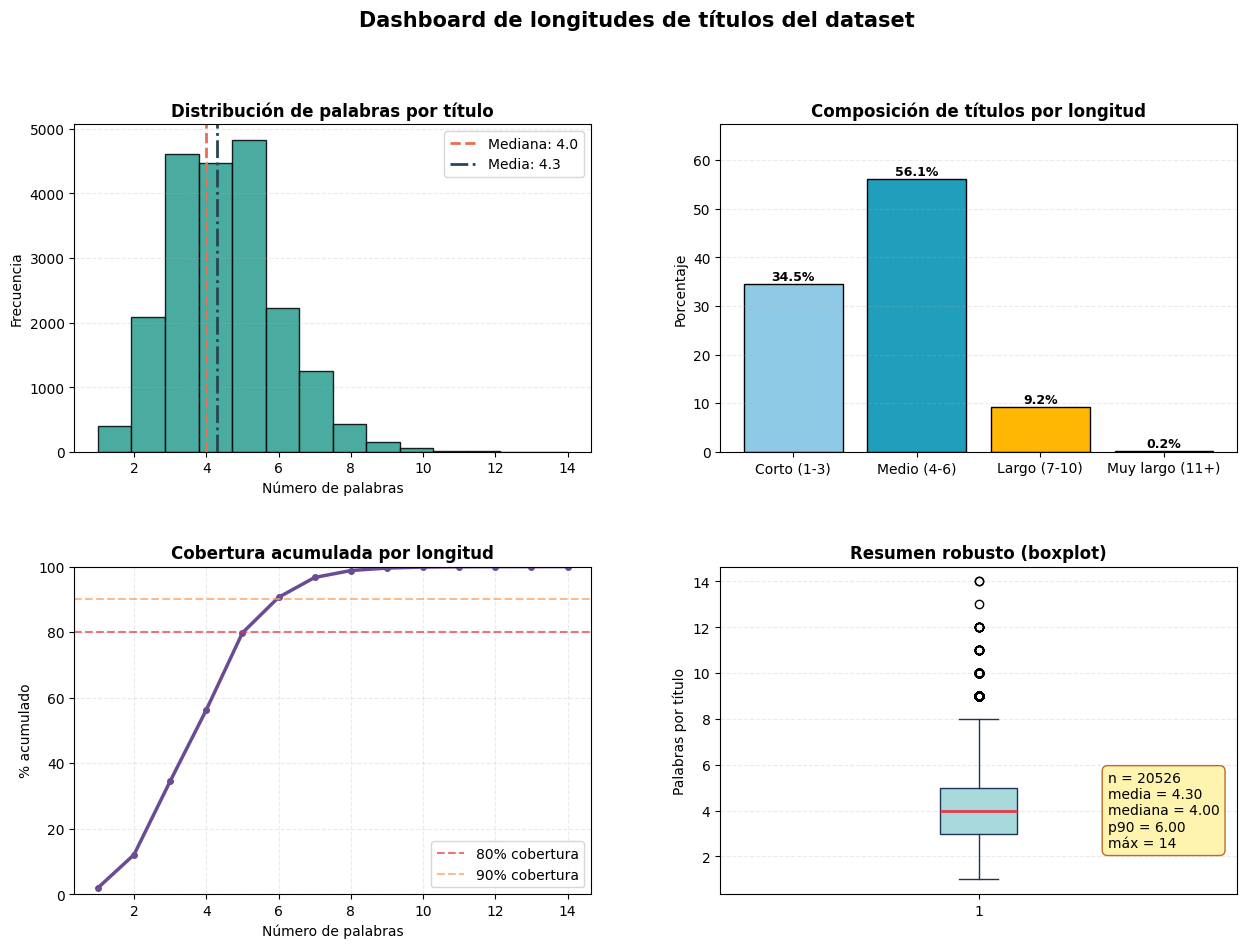

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dashboard del resultado anterior: distribución de longitudes de títulos
# La celda anterior dejó df['title'] como número de palabras por título.
if "df" not in globals() or "title" not in df.columns:
    raise ValueError("Ejecuta primero la celda anterior para crear df['title'].")

title_len = pd.to_numeric(df["title"], errors="coerce").dropna().astype(int)
if title_len.empty:
    raise ValueError("No hay datos válidos en df['title'] para graficar.")

stats = {
    "n": len(title_len),
    "media": title_len.mean(),
    "mediana": title_len.median(),
    "p90": title_len.quantile(0.90),
    "max": title_len.max(),
}

# Segmentos para conectar histogramas y composición
def to_bucket(x):
    if x <= 3:
        return "Corto (1-3)"
    if x <= 6:
        return "Medio (4-6)"
    if x <= 10:
        return "Largo (7-10)"
    return "Muy largo (11+)"

bucket = title_len.map(to_bucket)
bucket_order = ["Corto (1-3)", "Medio (4-6)", "Largo (7-10)", "Muy largo (11+)"]
bucket_dist = bucket.value_counts().reindex(bucket_order, fill_value=0)
bucket_pct = bucket_dist / bucket_dist.sum() * 100

# Curva acumulada para ver cobertura de longitudes
counts = title_len.value_counts().sort_index()
cum_pct = counts.cumsum() / counts.sum() * 100

fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.25)

# 1) Histograma principal
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(title_len, bins=min(25, max(8, title_len.nunique())), color="#2A9D8F", edgecolor="black", alpha=0.85)
ax1.axvline(stats["mediana"], color="#E76F51", linestyle="--", linewidth=2, label=f"Mediana: {stats['mediana']:.1f}")
ax1.axvline(stats["media"], color="#264653", linestyle="-.", linewidth=2, label=f"Media: {stats['media']:.1f}")
ax1.set_title("Distribución de palabras por título", fontweight="bold")
ax1.set_xlabel("Número de palabras")
ax1.set_ylabel("Frecuencia")
ax1.grid(axis="y", alpha=0.25, linestyle="--")
ax1.legend()

# 2) Composición por segmentos (relacionada con el histograma)
ax2 = fig.add_subplot(gs[0, 1])
bars = ax2.bar(bucket_order, bucket_pct.values, color=["#8ECAE6", "#219EBC", "#FFB703", "#FB8500"], edgecolor="black")
for b, p in zip(bars, bucket_pct.values):
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.8, f"{p:.1f}%", ha="center", fontsize=9, fontweight="bold")
ax2.set_title("Composición de títulos por longitud", fontweight="bold")
ax2.set_ylabel("Porcentaje")
ax2.set_ylim(0, max(bucket_pct.values) * 1.2)
ax2.grid(axis="y", alpha=0.25, linestyle="--")

# 3) Curva acumulada (conecta conteos con cobertura)
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(cum_pct.index, cum_pct.values, color="#6A4C93", linewidth=2.5, marker="o", markersize=4)
ax3.axhline(80, color="#E63946", linestyle="--", alpha=0.7, label="80% cobertura")
ax3.axhline(90, color="#F4A261", linestyle="--", alpha=0.7, label="90% cobertura")
ax3.set_title("Cobertura acumulada por longitud", fontweight="bold")
ax3.set_xlabel("Número de palabras")
ax3.set_ylabel("% acumulado")
ax3.set_ylim(0, 100)
ax3.grid(alpha=0.25, linestyle="--")
ax3.legend()

# 4) Resumen numérico + boxplot compacto
ax4 = fig.add_subplot(gs[1, 1])
ax4.boxplot(
    title_len,
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor="#A8DADC", color="#1D3557"),
    medianprops=dict(color="#E63946", linewidth=2),
    whiskerprops=dict(color="#1D3557"),
    capprops=dict(color="#1D3557"),
)
ax4.set_title("Resumen robusto (boxplot)", fontweight="bold")
ax4.set_ylabel("Palabras por título")
ax4.grid(axis="y", alpha=0.25, linestyle="--")

summary_txt = (
    f"n = {stats['n']}\n"
    f"media = {stats['media']:.2f}\n"
    f"mediana = {stats['mediana']:.2f}\n"
    f"p90 = {stats['p90']:.2f}\n"
    f"máx = {stats['max']}"
)
ax4.text(1.25, stats["mediana"], summary_txt, va="center", fontsize=10,
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#FFF3B0", edgecolor="#BC6C25"))

fig.suptitle("Dashboard de longitudes de títulos del dataset", fontsize=15, fontweight="bold", y=0.995)
plt.tight_layout()
plt.show()

### Análisis del resultado

El dashboard muestra una distribución **concentrada en títulos cortos**: la media está cerca de 4.3 palabras y la mediana en 4. Además, el 90% de los casos se alcanza alrededor de 6 palabras, lo que confirma baja dispersión y pocos outliers largos.

En términos de modelado, esto sugiere que el corpus tiene una estructura compacta y relativamente homogénea, útil para entrenar un modelo generativo con costos de cómputo moderados.

### Implicaciones para el preprocesamiento

- Un `max_length` moderado (por ejemplo, 8 a 16) suele cubrir bien el dataset.
- Se reduce el padding innecesario, mejorando eficiencia en memoria y tiempo.
- La tokenización por lotes es estable porque las secuencias tienen longitudes similares.
- Los títulos extremadamente largos pueden tratarse como casos excepcionales sin afectar el comportamiento general.

In [44]:
def preprocess_function(max_len):
    # Crea y devuelve una función de preprocesamiento parametrizada por max_len.
    # Este patrón permite reutilizar la misma lógica para distintos tamaños de secuencia.
    def _preprocess_function(examples):
        # Normaliza nulos para evitar errores en tokenización (None -> "").
        texts = [t if t is not None else "" for t in examples['title']]

        # Convierte texto a input_ids con:
        # - truncation: recorta secuencias largas
        # - padding='max_length': unifica longitud en cada ejemplo
        # Es compatible con ejecución en Colab y VSCode.
        return tokenizer(
            texts,
            max_length=max_len,
            truncation=True,
            padding='max_length',
        )

    return _preprocess_function

En modelos GPT para lenguaje causal, el insumo principal es `input_ids`. Por eso retiramos las columnas que no se usarán en el entrenamiento para simplificar el pipeline y reducir uso de memoria.

In [45]:
# Objetivo de esta celda:
# preparar un dataset tokenizado, limpio y listo para entrenar GPT con Hugging Face Trainer.
# El flujo funciona igual en Colab y en VSCode.

# 1) Restablece el formato original del dataset.
# Antes se usó formato pandas para EDA; aquí volvemos al formato nativo de datasets.
dataset.reset_format()

# 2) Selecciona el split que usaremos para construir entrenamiento/validación.
dataset_es = dataset['train']

# 3) Tokeniza por lotes para mejorar rendimiento.
# max_len=512 define longitud máxima; textos más largos se recortan.
tokenized_dataset = dataset_es.map(preprocess_function(max_len=512), batched=True)

# 4) Conserva solo input_ids.
# En este flujo de lenguaje causal, no necesitamos columnas auxiliares del dataset original.
tokenized_dataset = tokenized_dataset.remove_columns(
    [col for col in tokenized_dataset.column_names if col != 'input_ids']
)

# 5) Divide en train/test con semilla fija para reproducibilidad.
# El 90% queda para entrenamiento y el 10% para evaluación.
tokenized_dataset = tokenized_dataset.train_test_split(train_size=0.9, seed=42)

# 6) Convierte a tensores de PyTorch para compatibilidad directa con Trainer.
tokenized_dataset.set_format('torch')

# Verificación rápida de la estructura final.
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['input_ids'],
        num_rows: 18473
    })
    test: Dataset({
        features: ['input_ids'],
        num_rows: 2053
    })
})

En este punto definimos la configuración de entrenamiento para el ajuste fino de GPT-2.

La lógica es equivalente a la usada con BERT en Hugging Face Trainer, pero aquí el objetivo es **modelado causal de lenguaje** (predecir el siguiente token).

In [46]:
import torch
import pkg_resources

# Si IN_COLAB no existe (kernel reiniciado), lo inferimos automáticamente.
if "IN_COLAB" not in globals():
    installed_packages = [package.key for package in pkg_resources.working_set]
    IN_COLAB = "google-colab" in installed_packages

# Selección segura de dispositivo (compatible con Colab y VSCode)
cuda_ok = torch.cuda.is_available()

if cuda_ok:
    device = "cuda"
    if IN_COLAB:
        print("Colab detectado con CUDA activo.")
    else:
        print("Entorno local detectado con CUDA activo.")
    print(f"Dispositivo en uso: {device}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    device = "cpu"
    if IN_COLAB:
        print("Colab detectado sin CUDA activa. Se usará CPU (más lento).")
        print("Sugerencia: Entorno de ejecución > Cambiar tipo de entorno > GPU")
    else:
        print("Entorno local sin CUDA. Se usará CPU (más lento).")
        print("Sugerencia: verifica drivers NVIDIA/CUDA y la instalación de PyTorch con soporte GPU")
    print(f"Dispositivo en uso: {device}")

# Si el modelo existe en memoria, lo movemos al dispositivo seleccionado.
if "model" in globals():
    model = model.to(device)
else:
    print("Aviso: 'model' no está cargado todavía. Ejecuta primero la celda de carga del modelo.")

Entorno local detectado con CUDA activo.
Dispositivo en uso: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


In [47]:
import torch
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
)

# Si 'device' no está definido (ejecución fuera de orden), lo inferimos aquí.
if "device" not in globals():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"'device' no estaba definido. Se usará: {device}")

# ------------------------------------------------------------------
# Bootstrap de prerequisitos para permitir ejecución autónoma de celda
# ------------------------------------------------------------------
if "model_name" not in globals():
    model_name = "mrm8488/spanish-gpt2"

if "tokenizer" not in globals() or "model" not in globals():
    print("Cargando tokenizer/model porque no estaban en memoria...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    model.config.pad_token_id = tokenizer.pad_token_id
    model.resize_token_embeddings(len(tokenizer))

model = model.to(device)

if "tokenized_dataset" not in globals():
    print("Construyendo tokenized_dataset porque no estaba en memoria...")

    if "dataset" not in globals():
        dataset = load_dataset("Frorozcol/recetas-cocina")

    # Preprocesador local de respaldo si no existe preprocess_function
    if "preprocess_function" not in globals():
        def preprocess_function(max_len):
            def _preprocess_function(examples):
                texts = [t if t is not None else "" for t in examples['title']]
                return tokenizer(texts, max_length=max_len, truncation=True, padding='max_length')
            return _preprocess_function

    dataset.reset_format()
    dataset_es = dataset['train']
    tokenized_dataset = dataset_es.map(preprocess_function(max_len=512), batched=True)
    tokenized_dataset = tokenized_dataset.remove_columns(
        [col for col in tokenized_dataset.column_names if col != 'input_ids']
    )
    tokenized_dataset = tokenized_dataset.train_test_split(train_size=0.9, seed=42)
    tokenized_dataset.set_format('torch')

# ------------------------------------------------------------
# Configuración base del entrenamiento
# ------------------------------------------------------------
batch_size = 8 if device == "cuda" else 2
logging_steps = max(1, len(tokenized_dataset['train']) // batch_size)

# ------------------------------------------------------------
# Hiperparámetros de fine-tuning
# ------------------------------------------------------------
training_args = TrainingArguments(
    output_dir='./hf-gpt',
    num_train_epochs=10,
    learning_rate=2e-5,
    per_device_eval_batch_size=batch_size,
    per_device_train_batch_size=batch_size,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    disable_tqdm=False,
    logging_steps=logging_steps,
    report_to='none',
)

# ------------------------------------------------------------
# Construcción del Trainer
# ------------------------------------------------------------
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False),
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['test'],
)

print(f"Trainer configurado correctamente en {device} con batch_size={batch_size}.")

Trainer configurado correctamente en cuda con batch_size=8.


In [49]:
print("CUDA disponible:", torch.cuda.is_available())
print("Device del modelo:", next(model.parameters()).device)

CUDA disponible: True
Device del modelo: cuda:0


In [48]:
# Ejecuta el entrenamiento del modelo sobre el corpus tokenizado.
# %time permite medir el tiempo total de ejecución de la celda.
# Referencia aproximada: más rápido en Colab-GPU, más lento en CPU/local.

# Parche de compatibilidad para algunas combinaciones transformers/accelerate
# donde AcceleratedOptimizer llama optimizer.train()/eval() y AdamW no los implementa.
import torch

if not hasattr(torch.optim.Optimizer, "train"):
    torch.optim.Optimizer.train = lambda self: None
if not hasattr(torch.optim.Optimizer, "eval"):
    torch.optim.Optimizer.eval = lambda self: None

%time
trainer.train()

CPU times: total: 0 ns
Wall time: 0 ns


  8%|▊         | 1789/23100 [8:37:03<11:29:11,  1.94s/it]     

KeyboardInterrupt: 

Ahora observemos los resultados.

In [ ]:
# Genera texto con el modelo fine-tuned (ya altamente especializado en recetas)
# temperature=0.8 permite variabilidad controlada en la generación
output = model.generate(tokens, pad_token_id=tokenizer.eos_token_id, max_length=100, do_sample=True, temperature=0.8)
print(tokenizer.decode(output[0]))  # Output tendrá lenguaje y vocabulario culinario

In [ ]:
# Genera texto con eps=0.2 (20% greedy, 80% muestreo): mucha variabilidad
# Comparar con eps=1.0 muestra cómo el fine-tuning cambia el comportamiento del modelo
output_text, _ = generate(model, tokenizer, text, max_length=100, eps=0.2, device=device)
print(output_text)  # Output más creativo y diverso que el modelo base

## Descripción de resultados

En este notebook se trabajó con un modelo GPT-2 en español en dos etapas: (1) generación con el modelo base pre-entrenado y (2) fine-tuning sobre el dataset de recetas de cocina.

El entrenamiento se ejecutó con una configuración (10 épocas, `eval_strategy='no'`, `save_strategy='no'`, `fp16=True`) para reducir tiempo de cómputo y permitir iteraciones más ágiles.

## Conclusiones

- El pipeline completo se ejecutó correctamente: carga de datos, limpieza, tokenización, entrenamiento y generación.
- Filtrar a español antes del fine-tuning mejora la coherencia lingüística del ajuste y reduce ruido de ejemplos en otros idiomas.
- El modelo ajustado mostró cambio de estilo frente al modelo base, con salida más orientada al dominio del corpus usado para entrenamiento.
- En modelos generativos, la calidad final depende tanto de los hiperparámetros como de la curación del dataset; en este caso, el filtrado por idioma fue una mejora clave.
- Para iteración rápida, la configuración reducida de entrenamiento fue efectiva; como siguiente paso, conviene evaluar una corrida más larga con validación activa para comparar calidad de forma más rigurosa.